# 01 — Exploratory Data Analysis

**Course:** ADS504 — Machine Learning and Deep Learning for Data Science  
**Dataset:** [Bank Marketing (UCI)](https://archive.ics.uci.edu/dataset/222/bank+marketing)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 40)
sns.set_style('whitegrid')


Matplotlib is building the font cache; this may take a moment.


## Load data

Read the full UCI bank marketing file from `data/raw/`.


In [2]:
# Local path from notebooks/. On Colab, upload the file or point this to your Drive path.
DATA_PATH = '../data/raw/bank-full.csv'
df = pd.read_csv(DATA_PATH, sep=';')
print('Shape:', df.shape)
df.head()


Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Data overview

Check types, duplicates, and nulls before plotting.


In [3]:
df.info()
print('Duplicate rows:', df.duplicated().sum())
print('Null cells per column:')
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
Duplicate rows: 0
Null cells per column:
age          0
job          0
marital      0
education    

In [4]:
numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
target = 'y'

df[numeric_cols].describe().T.round(1)


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.9,10.6,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.3,3044.8,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.8,8.3,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.2,257.5,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.8,3.1,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.2,100.1,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.6,2.3,0.0,0.0,0.0,0.0,275.0


No duplicate rows and no NaNs. About 45k contacts with a mix of numeric and categorical features.


## Target variable

Predict whether a client subscribes to a term deposit (`y`).


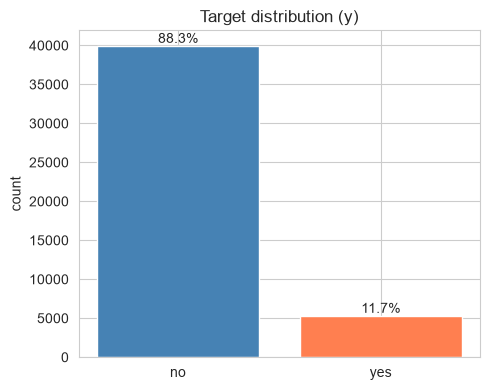

Yes rate: 11.7%


In [5]:
df['y_binary'] = (df['y'] == 'yes').astype(int)
base_rate = df['y_binary'].mean() * 100

vc = df['y'].value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(vc.index, vc.values, color=['steelblue', 'coral'])
ax.set_title('Target distribution (y)')
ax.set_ylabel('count')
for i, v in enumerate(vc.values):
    ax.text(i, v + 400, f'{v/len(df)*100:.1f}%', ha='center')
plt.tight_layout()
plt.show()

print(f'Yes rate: {base_rate:.1f}%')


Only about 12% subscribe. Accuracy will look high if we always predict no, so later we should use recall, F1, and ROC-AUC.


## Missing and coded values

Some fields use `unknown` or `pdays = -1` instead of NaN.


In [6]:
missing = {c: (df[c] == 'unknown').mean() * 100 for c in categorical_cols if (df[c] == 'unknown').any()}
missing['pdays == -1'] = (df['pdays'] == -1).mean() * 100
miss_s = pd.Series(missing).sort_values(ascending=False)
print(miss_s.round(1))

print('pdays == -1:', (df['pdays'] == -1).sum())
print('poutcome == unknown:', (df['poutcome'] == 'unknown').sum())
print('previous == 0:', (df['previous'] == 0).sum())


poutcome       81.7
pdays == -1    81.7
contact        28.8
education       4.1
job             0.6
dtype: float64
pdays == -1: 36954
poutcome == unknown: 36959
previous == 0: 36954


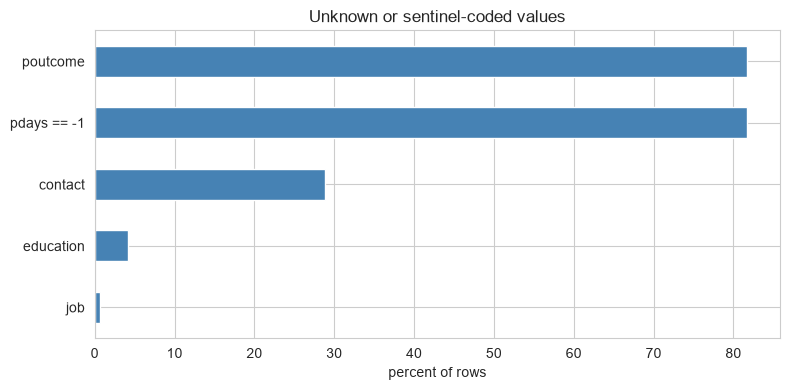

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
miss_s.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('percent of rows')
ax.set_title('Unknown or sentinel-coded values')
plt.tight_layout()
plt.show()


`poutcome` unknown, `pdays = -1`, and `previous = 0` line up. That means no prior contact, not broken data. Keep unknown as its own level in preprocessing.


## Numeric distributions

Look at shape, skew, and outliers for the continuous fields.


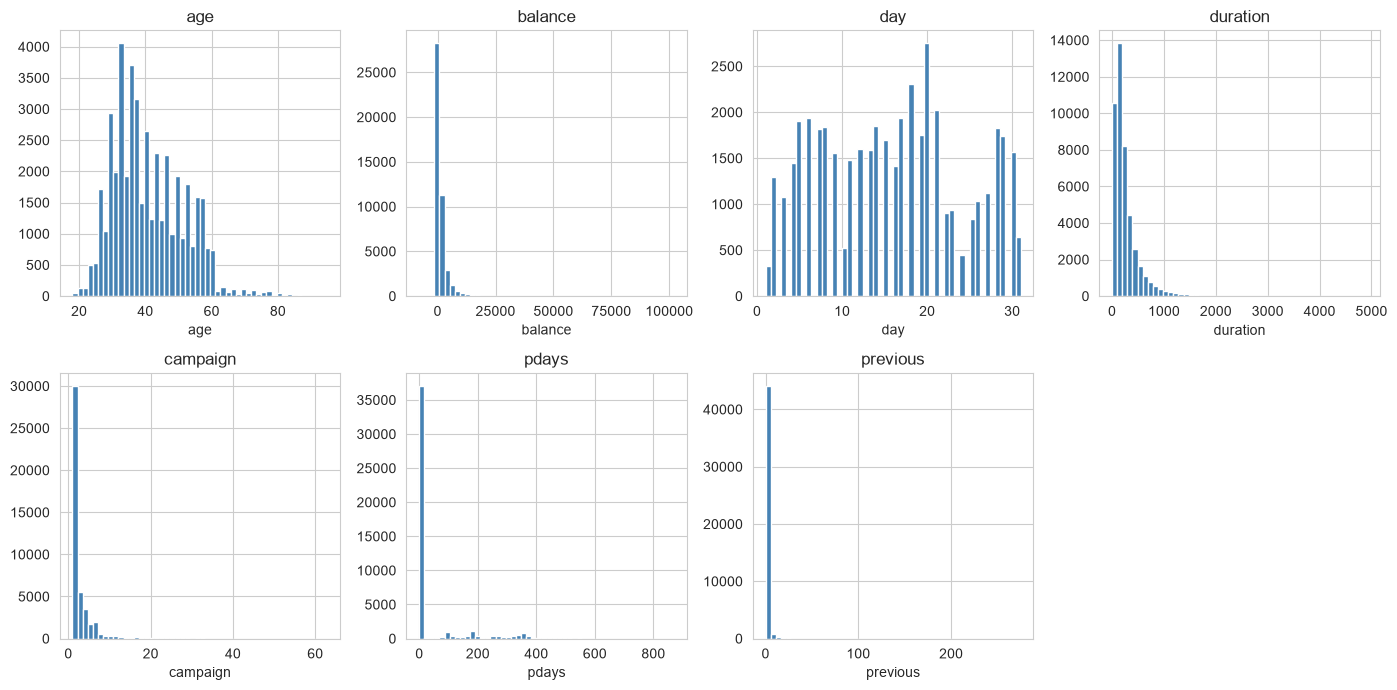

age          0.68
balance      8.36
day          0.09
duration     3.14
campaign     4.90
pdays        2.62
previous    41.85
dtype: float64


In [8]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, col in zip(axes.ravel(), ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']):
    ax.hist(df[col], bins=50, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel(col)
axes.ravel()[-1].axis('off')
plt.tight_layout()
plt.show()

print(df[numeric_cols].skew().round(2))


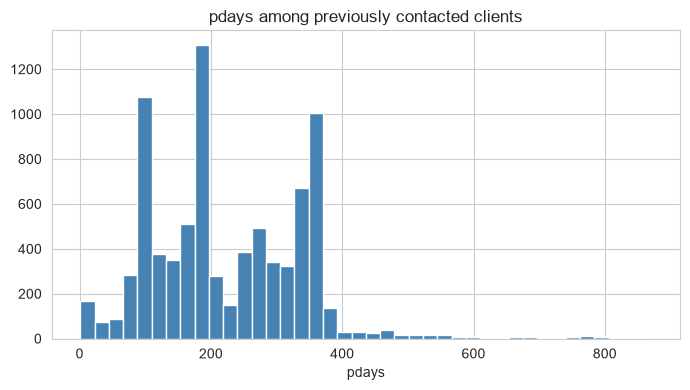

Previously contacted rows: 8257


In [9]:
# pdays is dominated by -1 (never contacted); plot contacted clients separately
contacted = df.loc[df['pdays'] != -1, 'pdays']
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(contacted, bins=40, color='steelblue', edgecolor='white')
ax.set_title('pdays among previously contacted clients')
ax.set_xlabel('pdays')
plt.tight_layout()
plt.show()
print('Previously contacted rows:', len(contacted))


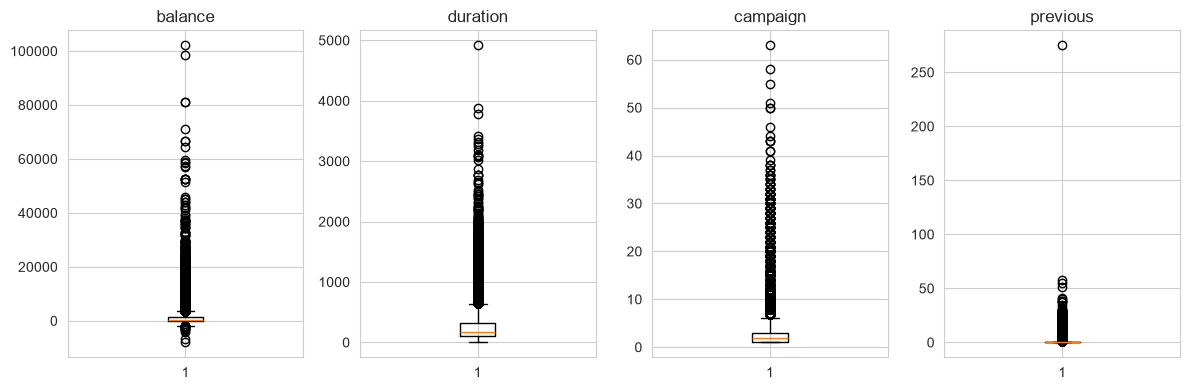

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for ax, col in zip(axes, ['balance', 'duration', 'campaign', 'previous']):
    ax.boxplot(df[col])
    ax.set_title(col)
plt.tight_layout()
plt.show()


Balance, campaign, previous, and duration are right-skewed. Extreme values look real (large balances, many calls), so we should transform them later instead of deleting rows. Day of month is fairly even. The main `pdays` spike is the never-contacted code.


## Numeric features by target

Compare numeric distributions for yes vs no (duration covered in the next section).


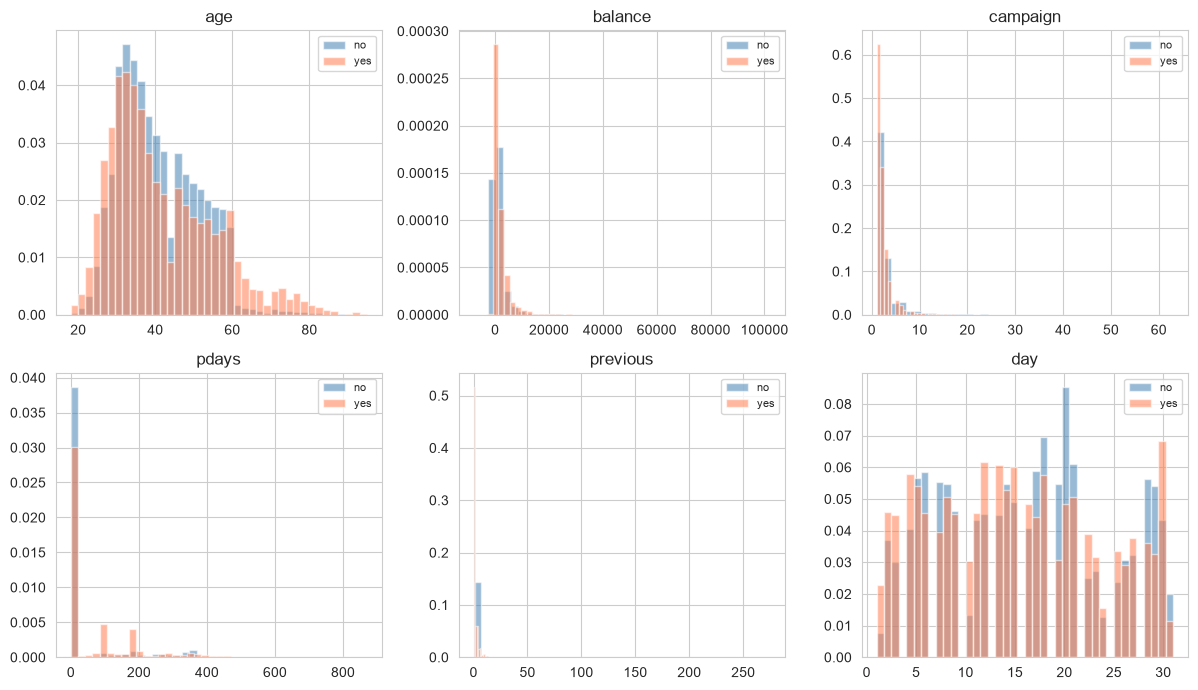

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
plot_cols = ['age', 'balance', 'campaign', 'pdays', 'previous', 'day']
for ax, col in zip(axes.ravel(), plot_cols):
    for lab, color in [('no', 'steelblue'), ('yes', 'coral')]:
        ax.hist(df.loc[df.y == lab, col], bins=40, alpha=0.55, color=color, label=lab, density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [12]:
df.groupby('y')[numeric_cols].median().round(1)


,age,balance,day,duration,campaign,pdays,previous
y,,,,,,,
no,39.0,417.0,16.0,164.0,2.0,-1.0,0.0
yes,38.0,733.0,15.0,426.0,2.0,-1.0,0.0


Yes clients show different prior-contact patterns and slightly different balances/ages. Duration is checked separately because of leakage.


## Correlations

Numeric associations, including the target.


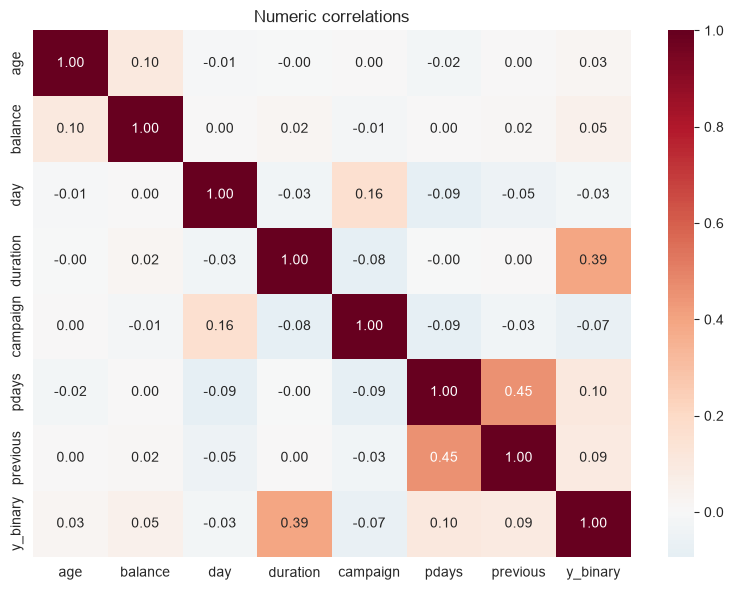

In [13]:
corr = df[numeric_cols + ['y_binary']].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Numeric correlations')
plt.tight_layout()
plt.show()


Most numeric features are weakly related to `y`. Duration is the exception. `pdays` and `previous` are related to each other.


## Duration and leakage

Duration is call length in seconds. It is only known after the call happens.


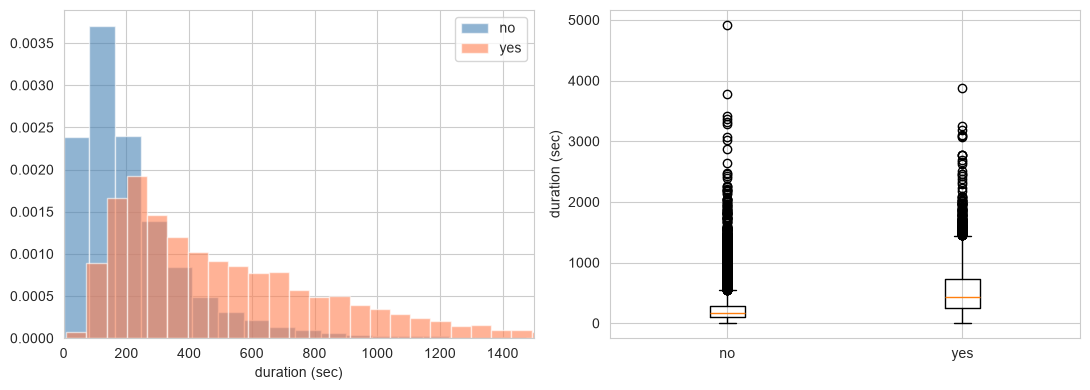

Correlation with target: 0.395


In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for lab, color in [('no', 'steelblue'), ('yes', 'coral')]:
    ax[0].hist(df.loc[df.y == lab, 'duration'], bins=60, alpha=0.6, color=color, label=lab, density=True)
ax[0].set_xlim(0, 1500)
ax[0].set_xlabel('duration (sec)')
ax[0].legend()

ax[1].boxplot([df.loc[df.y == 'no', 'duration'], df.loc[df.y == 'yes', 'duration']])
ax[1].set_xticklabels(['no', 'yes'])
ax[1].set_ylabel('duration (sec)')
plt.tight_layout()
plt.show()

print('Correlation with target:', round(df['duration'].corr(df['y_binary']), 3))


Strong link to the target, but including duration would leak future information. Drop it before modeling.


## Categorical features vs target

Subscription rate by category (red line = overall yes rate).


In [15]:
def subscription_rate(col, order=None):
    t = df.groupby(col)['y_binary'].agg(['mean', 'count'])
    t['rate_pct'] = t['mean'] * 100
    if order is not None:
        t = t.reindex(order)
    else:
        t = t.sort_values('rate_pct', ascending=False)
    return t

for col in ['job', 'education', 'marital', 'housing', 'loan', 'contact', 'poutcome', 'default']:
    print(f'\n{col}:')
    print(subscription_rate(col).round(1))



job:
               mean  count  rate_pct
job                                 
student         0.3    938      28.7
retired         0.2   2264      22.8
unemployed      0.2   1303      15.5
management      0.1   9458      13.8
admin.          0.1   5171      12.2
self-employed   0.1   1579      11.8
unknown         0.1    288      11.8
technician      0.1   7597      11.1
services        0.1   4154       8.9
housemaid       0.1   1240       8.8
entrepreneur    0.1   1487       8.3
blue-collar     0.1   9732       7.3

education:
           mean  count  rate_pct
education                       
tertiary    0.2  13301      15.0
unknown     0.1   1857      13.6
secondary   0.1  23202      10.6
primary     0.1   6851       8.6

marital:
          mean  count  rate_pct
marital                        
single     0.1  12790      14.9
divorced   0.1   5207      11.9
married    0.1  27214      10.1

housing:
         mean  count  rate_pct
housing                       
no        0.2  20081    

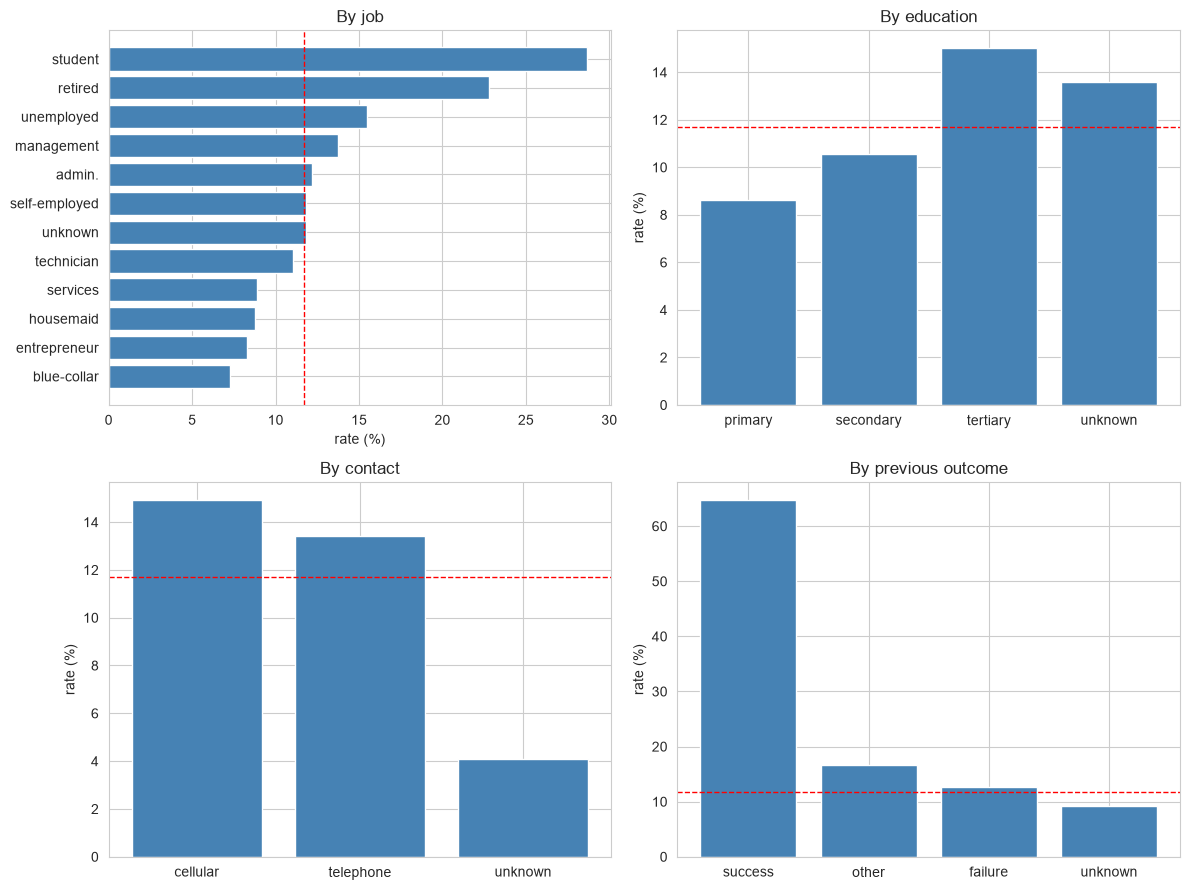

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

job_rates = subscription_rate('job').sort_values('rate_pct')
axes[0, 0].barh(job_rates.index.astype(str), job_rates['rate_pct'], color='steelblue')
axes[0, 0].axvline(base_rate, color='red', linestyle='--', linewidth=1)
axes[0, 0].set_title('By job')
axes[0, 0].set_xlabel('rate (%)')

edu_order = ['primary', 'secondary', 'tertiary', 'unknown']
edu_rates = subscription_rate('education', order=edu_order)
axes[0, 1].bar(edu_rates.index.astype(str), edu_rates['rate_pct'], color='steelblue')
axes[0, 1].axhline(base_rate, color='red', linestyle='--', linewidth=1)
axes[0, 1].set_title('By education')
axes[0, 1].set_ylabel('rate (%)')

contact_rates = subscription_rate('contact')
axes[1, 0].bar(contact_rates.index.astype(str), contact_rates['rate_pct'], color='steelblue')
axes[1, 0].axhline(base_rate, color='red', linestyle='--', linewidth=1)
axes[1, 0].set_title('By contact')
axes[1, 0].set_ylabel('rate (%)')

pout_rates = subscription_rate('poutcome')
axes[1, 1].bar(pout_rates.index.astype(str), pout_rates['rate_pct'], color='steelblue')
axes[1, 1].axhline(base_rate, color='red', linestyle='--', linewidth=1)
axes[1, 1].set_title('By previous outcome')
axes[1, 1].set_ylabel('rate (%)')

plt.tight_layout()
plt.show()


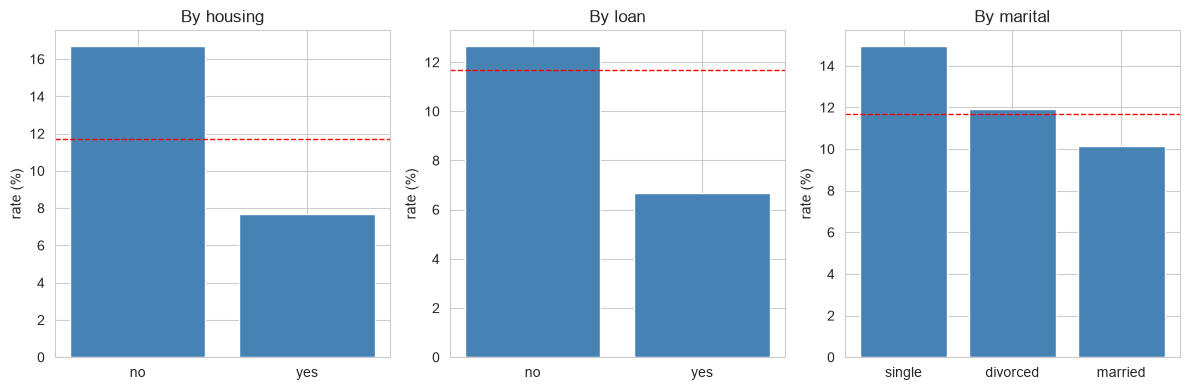

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ['housing', 'loan', 'marital']):
    rates = subscription_rate(col)
    ax.bar(rates.index.astype(str), rates['rate_pct'], color='steelblue')
    ax.axhline(base_rate, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'By {col}')
    ax.set_ylabel('rate (%)')
plt.tight_layout()
plt.show()


Biggest categorical signals: previous campaign success, contact type, job, and education. Clients without housing or personal loans convert a bit higher. Some groups are small (students, rare months), so those rates are noisier.


## Month: call volume vs conversion

Compare how many calls were made each month with the subscription rate.


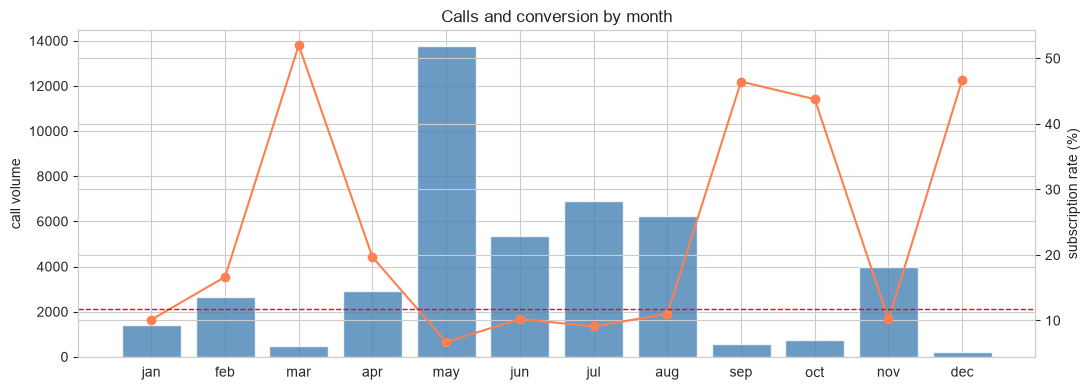

,mean,count,rate_pct
month,,,
jan,0.1,1403,10.1
feb,0.2,2649,16.6
mar,0.5,477,52.0
apr,0.2,2932,19.7
may,0.1,13766,6.7
jun,0.1,5341,10.2
jul,0.1,6895,9.1
aug,0.1,6247,11.0
sep,0.5,579,46.5


In [18]:
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_stats = df.groupby('month')['y_binary'].agg(['mean', 'count']).reindex(month_order)
month_stats['rate_pct'] = month_stats['mean'] * 100

fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.bar(month_order, month_stats['count'], color='steelblue', alpha=0.8)
ax1.set_ylabel('call volume')
ax2 = ax1.twinx()
ax2.plot(month_order, month_stats['rate_pct'], color='coral', marker='o')
ax2.axhline(base_rate, color='red', linestyle='--', linewidth=1)
ax2.set_ylabel('subscription rate (%)')
ax1.set_title('Calls and conversion by month')
plt.tight_layout()
plt.show()

month_stats.round(1)


May has the most calls but a low conversion rate. Months like March, September, October, and December convert much better with far fewer calls.


## Campaign intensity

How many contacts during this campaign, and how does that relate to the outcome.


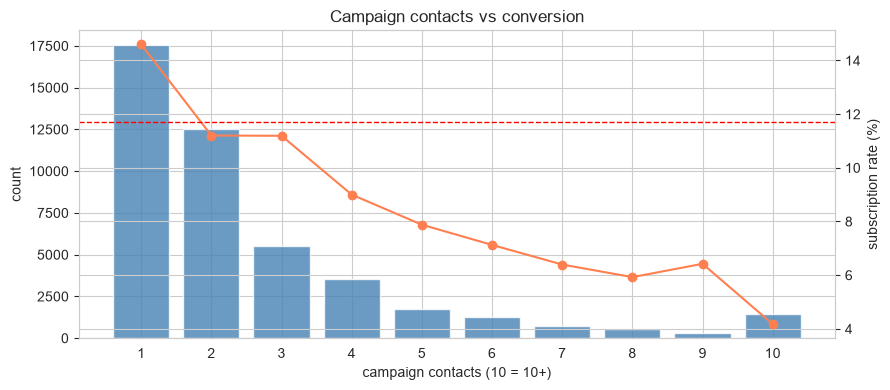

In [19]:
# Cap display for readability; raw campaign goes higher
campaign_cap = df['campaign'].clip(upper=10)
camp = pd.DataFrame({'campaign_capped': campaign_cap, 'y_binary': df['y_binary']})
camp_rates = camp.groupby('campaign_capped')['y_binary'].agg(['mean', 'count'])
camp_rates['rate_pct'] = camp_rates['mean'] * 100

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.bar(camp_rates.index.astype(str), camp_rates['count'], color='steelblue', alpha=0.8)
ax1.set_xlabel('campaign contacts (10 = 10+)')
ax1.set_ylabel('count')
ax2 = ax1.twinx()
ax2.plot(camp_rates.index.astype(str), camp_rates['rate_pct'], color='coral', marker='o')
ax2.axhline(base_rate, color='red', linestyle='--', linewidth=1)
ax2.set_ylabel('subscription rate (%)')
ax1.set_title('Campaign contacts vs conversion')
plt.tight_layout()
plt.show()


Conversion drops as more follow-up calls are made in the same campaign. Extra contacts past the first few look less useful.


## Cross-tabulations

Simple interactions between a few categorical features.


In [20]:
print('Subscription rate (%) by housing x loan')
print(pd.crosstab(df['housing'], df['loan'], values=df['y_binary'], aggfunc='mean').round(3) * 100)

print('\nSubscription rate (%) by contact x poutcome')
print(pd.crosstab(df['contact'], df['poutcome'], values=df['y_binary'], aggfunc='mean').round(3) * 100)

print('\nSubscription rate (%) by education x marital')
print(pd.crosstab(df['education'], df['marital'], values=df['y_binary'], aggfunc='mean').round(3) * 100)


Subscription rate (%) by housing x loan
loan       no  yes
housing           
no       18.2  7.6
yes       8.0  6.1

Subscription rate (%) by contact x poutcome
poutcome   failure  other  success  unknown
contact                                    
cellular      12.7   17.1     65.0     12.0
telephone     12.0   12.5     65.8     11.1
unknown       12.9   18.5     25.0      4.0

Subscription rate (%) by education x marital
marital    divorced  married  single
education                           
primary        13.8      7.5    10.7
secondary      10.3      9.5    12.9
tertiary       13.8     13.0    18.4
unknown        14.2     12.2    16.3


No housing + no loan does best. Previous success still dominates when combined with contact type.


## Age

Subscription rate across age bands.


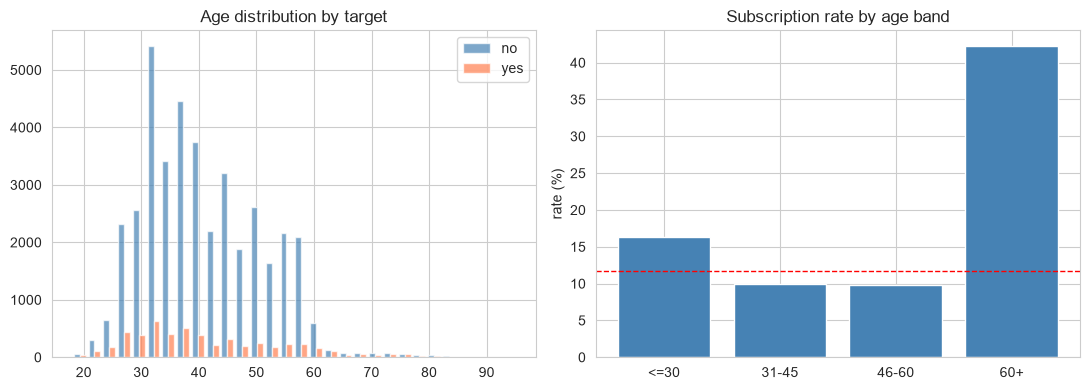

,mean,count,rate_pct
age_band,,,
<=30,0.2,7030,16.3
31-45,0.1,23733,9.9
46-60,0.1,13260,9.8
60+,0.4,1188,42.3


In [21]:
age_order = ['<=30', '31-45', '46-60', '60+']
df['age_band'] = pd.cut(df['age'], bins=[0, 30, 45, 60, 100], labels=age_order)
age_rates = subscription_rate('age_band', order=age_order)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist([df.loc[df.y == 'no', 'age'], df.loc[df.y == 'yes', 'age']],
             bins=30, label=['no', 'yes'], color=['steelblue', 'coral'], alpha=0.7)
axes[0].set_title('Age distribution by target')
axes[0].legend()

axes[1].bar(age_order, age_rates.loc[age_order, 'rate_pct'], color='steelblue')
axes[1].axhline(base_rate, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Subscription rate by age band')
axes[1].set_ylabel('rate (%)')
plt.tight_layout()
plt.show()

age_rates.loc[age_order].round(1)


Younger clients and those 60+ convert above average. The middle age bands are closer to the overall rate.


## Balance bands

Rough check of account balance vs subscription.


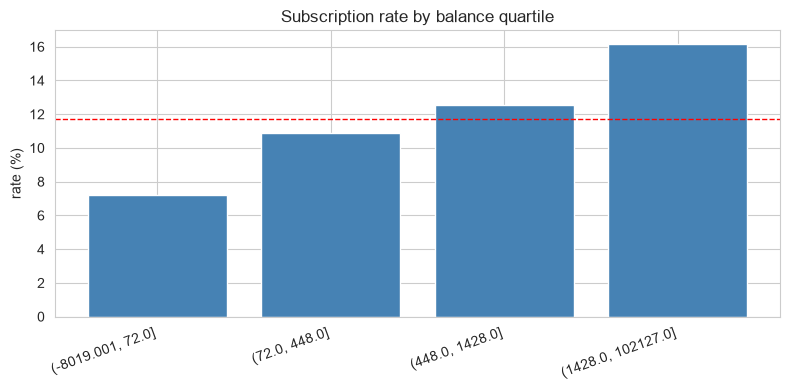

,mean,count,rate_pct
balance_band,,,
"(-8019.001, 72.0]",0.1,11317,7.2
"(72.0, 448.0]",0.1,11291,10.9
"(448.0, 1428.0]",0.1,11306,12.5
"(1428.0, 102127.0]",0.2,11297,16.2


In [22]:
df['balance_band'] = pd.qcut(df['balance'], q=4, duplicates='drop')
# keep quartile order (low to high), not rate order
bal_order = list(df['balance_band'].cat.categories)
bal_rates = subscription_rate('balance_band', order=bal_order)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(bal_order)), bal_rates.loc[bal_order, 'rate_pct'], color='steelblue')
ax.set_xticks(range(len(bal_order)))
ax.set_xticklabels([str(x) for x in bal_order], rotation=20, ha='right')
ax.axhline(base_rate, color='red', linestyle='--', linewidth=1)
ax.set_ylabel('rate (%)')
ax.set_title('Subscription rate by balance quartile')
plt.tight_layout()
plt.show()

bal_rates.loc[bal_order].round(1)


Higher balance quartiles convert a bit more often, but the gap is smaller than for poutcome or month.


## Summary

- 45,211 rows, no duplicates or NaNs. Unknown and `pdays = -1` mostly mean no prior contact.
- Target is imbalanced (~12% yes), so accuracy alone is a weak metric.
- Strong categorical signals: poutcome, contact, job, education, month.
- Campaign intensity and balance matter some; age has a mild U-shape.
- Duration is strongly related to y but is leakage and should be dropped.
- Numeric features are skewed; plan transforms and encoding in preprocessing.
